    
### DFL 전체 파이프라인 (Forward Pass)

    Args:
        z          : (batch, input_dim)  - 입력 피처
        r_real     : (batch, N, m)       - 실현 수익률 (ground truth)
        pred_model : PredictionModel
        opt_layer  : CvxpyLayer
        n1         : drawdown 한도 비율
        C          : 자본 규모
        d          : 연수
        x_min      : 최소 비중
        x_max      : 최대 비중
        lam        : MDD 패널티 가중치
    
    Returns:
        dict with keys:
            r_hat   : (batch, N, m)  예측 수익률
            y_hat   : (batch, N, m)  예측 누적 수익률
            x_star  : (batch, m)     최적 포트폴리오
            y_real  : (batch, N, m)  실현 누적 수익률
            w_real  : (batch, N)     실현 포트폴리오 경로
            R_real  : (batch,)       실현 수익률
            M_real  : (batch,)       실현 MDD
            loss    : scalar         DFL Loss

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import torch
import cvxpy as cp
from cvxpylayers.torch import CvxpyLayer
import yfinance as yf
import random
from dataclasses import dataclass
from typing import Dict, Tuple
from tqdm import tqdm
import itertools
import torch.nn as nn
import torch.optim as optim


    
    
### MDD Formulation을 cvxpylayers로 구성

    목적함수:
        max  (1/dC) * y_hat(N)^T x
        (dC는 상수이므로 y_hat(N)^T x 최대화와 동치)

    제약식:
        u_k - y_hat_k^T x <= n1 * C,    k = 1,...,N   (drawdown 상한)
        u_k >= y_hat_k^T x,              k = 1,...,N   (running max >= 현재값)
        u_k >= u_{k-1},                  k = 1,...,N   (running max 단조증가)
        u_0 = 0
        x_min <= x_i <= x_max,          i = 1,...,m   (box constraint)

    Parameters (cvxpy):
        Y_hat : (N, m) - 예측 누적 수익률 경로 (각 행이 y_hat(t))
        n1C   : scalar - 허용 최대 drawdown 한도 (n1 * C)
        x_min : scalar
        x_max : scalar

    Returns:
        CvxpyLayer - differentiable optimization layer
    

In [16]:


N_STOCKS   = 10
N_DAYS     = 252
LOOKBACK   = 21   
HORIZON    = 21   

INPUT_DIM  = LOOKBACK * N_STOCKS   
HIDDEN_DIM = 64
N          = HORIZON               
M          = N_STOCKS

n1    = 0.10  
C     = 1.0    
d     = float(N)  
x_min = 0.0    
x_max = 0.30   
lam   = 1.0    

EPOCHS     = 50
BATCH_SIZE = 16
LR         = 1e-3

In [17]:
# 1. Random Data 
np.random.seed(42)
torch.manual_seed(42)

stock_names = [f"S{i+1}" for i in range(N_STOCKS)]
mu    = np.random.uniform(0.001, 0.01, N_STOCKS)
sigma = np.random.uniform(0.01,   0.05,  N_STOCKS)
returns_np  = np.random.normal(mu, sigma, size=(N_DAYS, N_STOCKS))  # (252, 10)

dates       = pd.bdate_range(end="2025-12-31", periods=N_DAYS)
returns_df  = pd.DataFrame(returns_np, index=dates, columns=stock_names)

IS_END_IDX  = N_DAYS // 2   # 126  ── IS/OOS boundary
BT_START    = IS_END_IDX    # backtest starts here

print(f"IS  : {dates[0].date()} → {dates[IS_END_IDX-1].date()}  ({IS_END_IDX} days)")
print(f"BT  : {dates[BT_START].date()} → {dates[-1].date()}  ({N_DAYS - BT_START} days)")


IS  : 2025-01-14 → 2025-07-08  (126 days)
BT  : 2025-07-09 → 2025-12-31  (126 days)


In [18]:
def make_windows(arr, lookback, horizon, start, end):
    samples = []
    for t in range(start, end - horizon + 1):
        z      = arr[t - lookback : t].flatten()   # (lookback * m,)
        r_real = arr[t : t + horizon]              # (N, m)
        samples.append((z, r_real))
    return samples

# IS samples  (need lookback history → start from index LOOKBACK)
is_samples    = make_windows(returns_np, LOOKBACK, HORIZON,
                              start=LOOKBACK, end=IS_END_IDX)

# BT samples  (all windows in OOS, step by step)
bt_samples_all = make_windows(returns_np, LOOKBACK, HORIZON,
                               start=BT_START, end=N_DAYS)

# Monthly rebalancing: one window per HORIZON days
rebal_samples = bt_samples_all[::HORIZON]

print(f"\nIS training windows : {len(is_samples)}")
print(f"BT rebal windows    : {len(rebal_samples)}")



IS training windows : 85
BT rebal windows    : 6



── PTO-MDD Training (MSE) ──
  Epoch   1/50  mse = 0.005431
  Epoch   5/50  mse = 0.001057
  Epoch  10/50  mse = 0.000763
  Epoch  15/50  mse = 0.000735
  Epoch  20/50  mse = 0.000730
  Epoch  25/50  mse = 0.000719
  Epoch  30/50  mse = 0.000706
  Epoch  35/50  mse = 0.000697
  Epoch  40/50  mse = 0.000682
  Epoch  45/50  mse = 0.000666
  Epoch  50/50  mse = 0.000654

── PTO-MVO Training (MSE) ──
  Epoch   1/50  mse = 0.005101
  Epoch   5/50  mse = 0.001109
  Epoch  10/50  mse = 0.000765
  Epoch  15/50  mse = 0.000741
  Epoch  20/50  mse = 0.000730
  Epoch  25/50  mse = 0.000715
  Epoch  30/50  mse = 0.000697
  Epoch  35/50  mse = 0.000675
  Epoch  40/50  mse = 0.000661
  Epoch  45/50  mse = 0.000633
  Epoch  50/50  mse = 0.000621

── IS Training ──
  Epoch   1/50  loss = 0.028322
  Epoch   5/50  loss = 0.026803
  Epoch  10/50  loss = 0.029448
  Epoch  15/50  loss = 0.027903
  Epoch  20/50  loss = 0.027903
  Epoch  25/50  loss = 0.028630
  Epoch  30/50  loss = 0.026369
  Epoch  35/50 

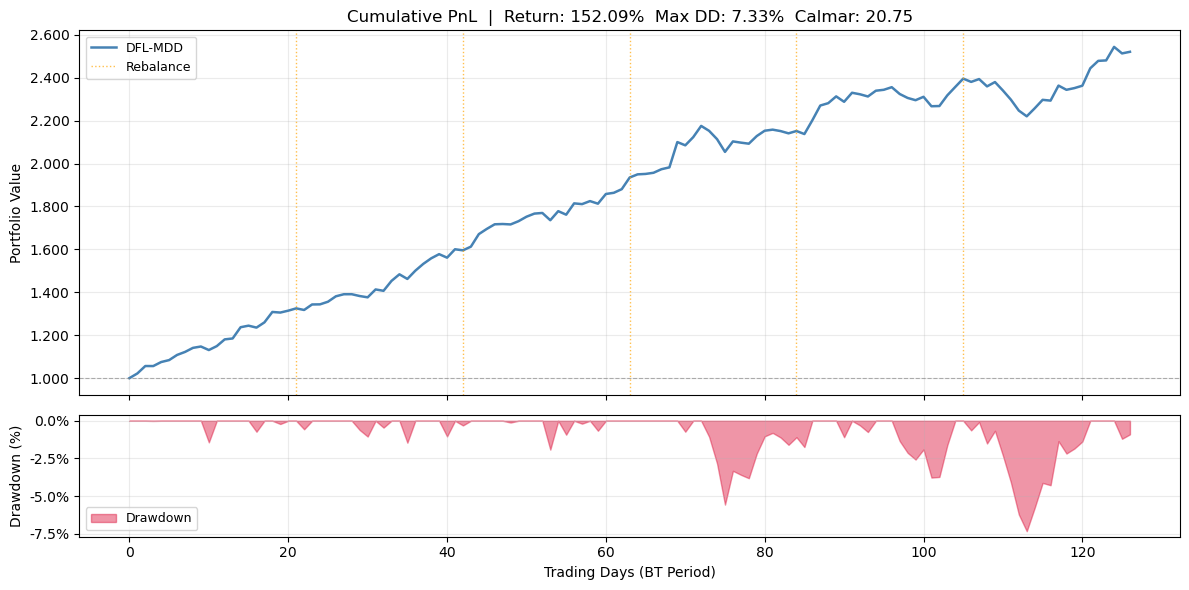


── PnL Summary (DFL-MDD) ──
  Final Value  : 2.5209
  Total Return : 152.0902%
  Max Drawdown : 7.3290%
  Calmar Ratio : 20.7519


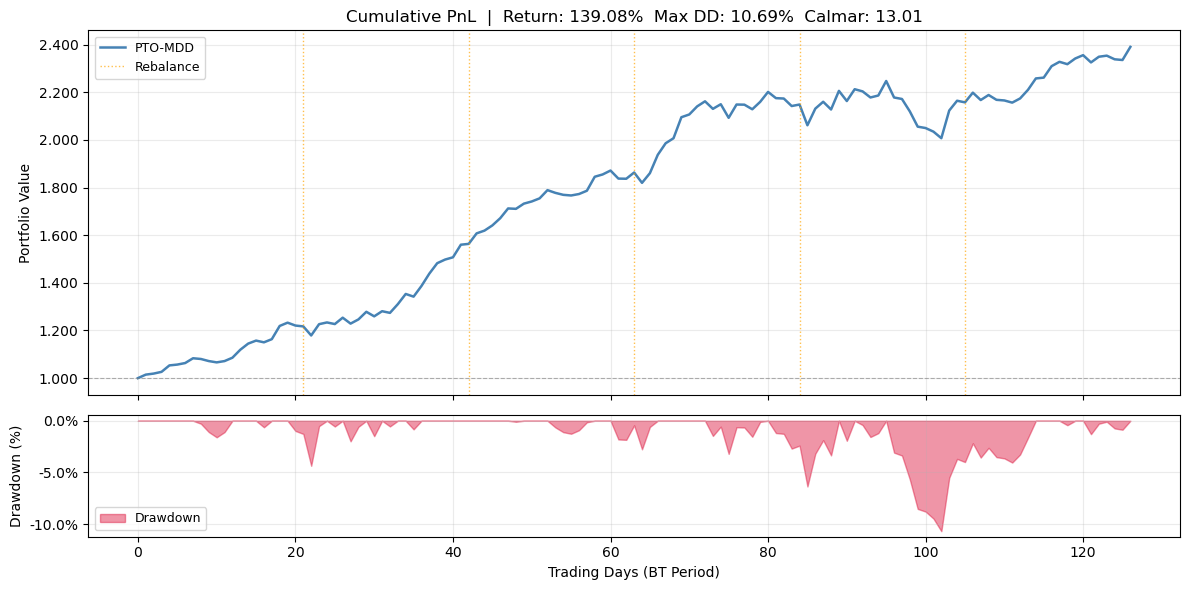


── PnL Summary (PTO-MDD) ──
  Final Value  : 2.3908
  Total Return : 139.0778%
  Max Drawdown : 10.6873%
  Calmar Ratio : 13.0134


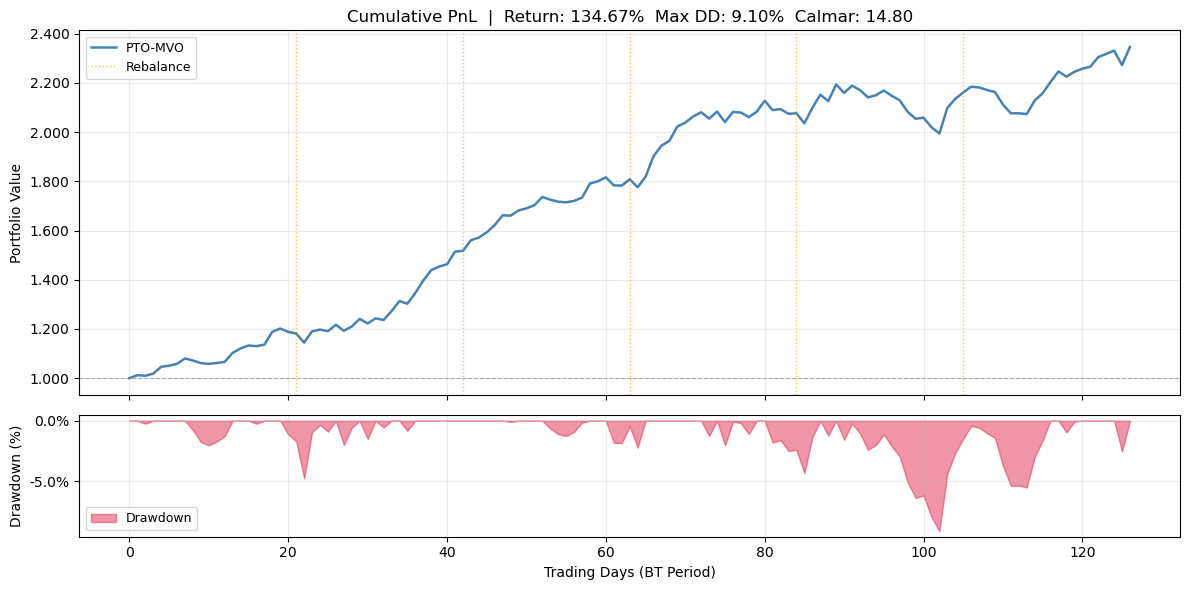


── PnL Summary (PTO-MVO) ──
  Final Value  : 2.3467
  Total Return : 134.6675%
  Max Drawdown : 9.0967%
  Calmar Ratio : 14.8041


In [21]:


from dfl_mdd import (
    PredictionModel,
    build_optimization_layer,
    solve_portfolio,
    compute_cumulative_path,
    compute_realized_path,
    compute_return,
    compute_max_drawdown,
    dfl_loss,
    forward_pass,
    backtest_dfl_mdd,
    plot_pnl,
)

from pto_mdd  import train_pto_mdd,  backtest_pto_mdd
from pto_mvo  import train_pto_mvo,  backtest_pto_mvo 

# 각 모델은 독립적인 PredictionModel 인스턴스 사용 (가중치 공유 X)
model_pto_mdd = PredictionModel(INPUT_DIM, HIDDEN_DIM, N, M)
model_pto_mvo = PredictionModel(INPUT_DIM, HIDDEN_DIM, N, M)

train_pto_mdd(model_pto_mdd, is_samples, EPOCHS, BATCH_SIZE, LR)
train_pto_mvo(model_pto_mvo, is_samples, EPOCHS, BATCH_SIZE, LR)

# 시드 재고정
np.random.seed(42)
torch.manual_seed(42)

pred_model = PredictionModel(INPUT_DIM, HIDDEN_DIM, N, M)
opt_layer  = build_optimization_layer(N, M)
optimizer  = optim.Adam(pred_model.parameters(), lr=LR)

def to_tensors(samples):
    zs      = torch.tensor(np.array([s[0] for s in samples]), dtype=torch.float32)
    r_reals = torch.tensor(np.array([s[1] for s in samples]), dtype=torch.float32)
    return zs, r_reals   # (B, input_dim),  (B, N, m)

zs_is, rs_is = to_tensors(is_samples)


print("\n── IS Training ──")
pred_model.train()

for epoch in range(EPOCHS):
    perm   = torch.randperm(len(is_samples))
    ep_loss = []

    for i in range(0, len(is_samples), BATCH_SIZE):
        idx = perm[i : i + BATCH_SIZE]
        z_b = zs_is[idx]
        r_b = rs_is[idx]

        optimizer.zero_grad()
        result = forward_pass(z_b, r_b, pred_model, opt_layer,
                              n1, C, d, x_min, x_max, lam)
        result["loss"].backward()
        optimizer.step()
        ep_loss.append(result["loss"].item())

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"  Epoch {epoch+1:3d}/{EPOCHS}  loss = {np.mean(ep_loss):.6f}")


bt_dfl_mdd = backtest_dfl_mdd(
    pred_model    = pred_model,
    opt_layer     = opt_layer,
    rebal_samples = rebal_samples,
    N             = HORIZON,
    d             = d,
    C             = C,
    n1            = n1,
    x_min         = x_min,
    x_max         = x_max,
    stock_names   = stock_names,
)



bt_pto_mdd = backtest_pto_mdd(
    pred_model   = model_pto_mdd,
    rebal_samples= rebal_samples,
    N            = HORIZON,
    d            = d,
    C            = C,
    n1           = n1,
    x_min        = x_min,
    x_max        = x_max,
    stock_names  = stock_names,
)

bt_pto_mvo = backtest_pto_mvo(
    pred_model   = model_pto_mvo,
    rebal_samples= rebal_samples,
    N            = HORIZON,
    d            = d,
    C            = C,
    lam_mvo      = 1.0,
    x_min        = x_min,
    x_max        = x_max,
    stock_names  = stock_names,
)

plot_pnl(bt_dfl_mdd, horizon=HORIZON, label = "DFL-MDD")
plot_pnl(bt_pto_mdd, horizon=HORIZON, label = 'PTO-MDD')
plot_pnl(bt_pto_mvo, horizon=HORIZON, label = 'PTO-MVO')
